# Lecture : Graph Convolutional Networks

## Lab 04 : GatedGCNs -- Solution

### Xavier Bresson, Nian Liu, Zhou Wei

Bresson, Laurent, Residual Gated Graph ConvNets, 2017  
https://arxiv.org/pdf/1711.07553

This notebook is the PyG mirror of the original DGL notebook. The GatedGCN message passing is implemented explicitly with `edge_index`; no pre-built GCN layer is used.

In [1]:
# For Google Colaboratory
import sys, os
if 'google.colab' in sys.modules:
    # mount Google Drive
    from google.colab import drive
    drive.mount('/content/gdrive')
    path_to_file = '/content/gdrive/My Drive/CS5284_2026_codes/06_Graph_Convnets'
    print(path_to_file)
    os.chdir(path_to_file)
    !pwd
    # Match the PyG version used in the course environment.
    !pip -q install torch_geometric==2.5.1

In [2]:
# Libraries
import math
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from torch_geometric.data import Batch, Data
from torch_geometric.nn import MessagePassing, global_mean_pool
from torch_geometric.utils import add_self_loops, degree, from_networkx, to_networkx

## Recreate DGL's MiniGCDataset with PyG

PyG does not provide DGL's `MiniGCDataset`, so we recreate the same eight graph classes with NetworkX and wrap every graph as a PyG `Data` object. Each graph contains both directions of every undirected edge and self-loops, matching the original DGL dataset.

In [3]:
class MiniGCDataset(Dataset):
    """PyG version of DGL's synthetic MiniGCDataset."""

    def __init__(self, num_graphs, min_num_v, max_num_v, seed=0):
        self.num_graphs = num_graphs
        self.min_num_v = min_num_v
        self.max_num_v = max_num_v
        self.seed = seed
        self.graphs = []
        self.labels = []
        self._generate(seed)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx], self.labels[idx]

    @staticmethod
    def _to_pyg_graph(graph):
        # PyG represents an undirected NetworkX graph with both edge directions.
        graph = graph.to_directed()
        data = from_networkx(graph)
        data.edge_index, _ = add_self_loops(
            data.edge_index, num_nodes=data.num_nodes
        )
        return data

    def _generate(self, seed):
        rng = np.random.RandomState(seed)
        generators = [
            self._gen_cycle,
            self._gen_star,
            self._gen_wheel,
            self._gen_lollipop,
            self._gen_hypercube,
            self._gen_grid,
            self._gen_clique,
            self._gen_circular_ladder,
        ]
        graphs = []
        labels = []
        counts = [self.num_graphs // 8] * 7
        counts.append(self.num_graphs - sum(counts))
        for label, (generator, count) in enumerate(zip(generators, counts)):
            for _ in range(count):
                graph = generator(rng)
                graphs.append(self._to_pyg_graph(graph))
                labels.append(label)
        self.graphs = graphs
        self.labels = torch.tensor(labels, dtype=torch.long)

    def _random_num_v(self, rng):
        return rng.randint(self.min_num_v, self.max_num_v)

    def _gen_cycle(self, rng):
        return nx.cycle_graph(self._random_num_v(rng))

    def _gen_star(self, rng):
        return nx.star_graph(self._random_num_v(rng) - 1)

    def _gen_wheel(self, rng):
        return nx.wheel_graph(self._random_num_v(rng))

    def _gen_lollipop(self, rng):
        num_v = self._random_num_v(rng)
        path_len = rng.randint(2, num_v // 2)
        return nx.lollipop_graph(m=num_v - path_len, n=path_len)

    def _gen_hypercube(self, rng):
        num_v = self._random_num_v(rng)
        graph = nx.hypercube_graph(int(math.log(num_v, 2)))
        return nx.convert_node_labels_to_integers(graph)

    def _gen_grid(self, rng):
        num_v = self._random_num_v(rng)
        n_rows = rng.randint(2, num_v // 2)
        n_cols = num_v // n_rows
        graph = nx.grid_graph([n_rows, n_cols])
        return nx.convert_node_labels_to_integers(graph)

    def _gen_clique(self, rng):
        return nx.complete_graph(self._random_num_v(rng))

    def _gen_circular_ladder(self, rng):
        return nx.circular_ladder_graph(self._random_num_v(rng) // 2)

## Visualize the artificial graph dataset used in this notebook

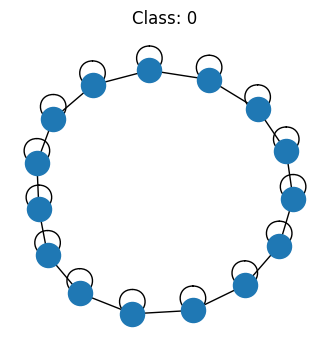

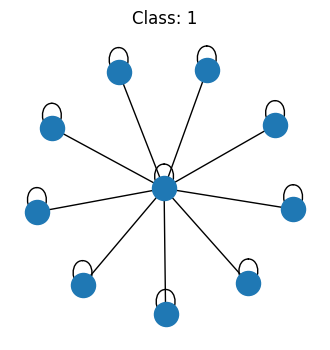

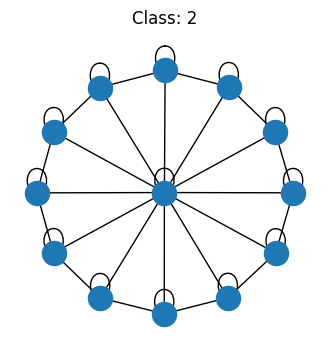

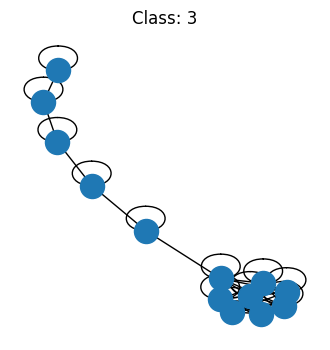

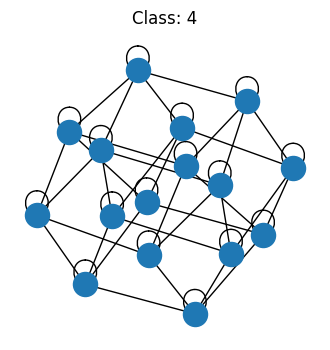

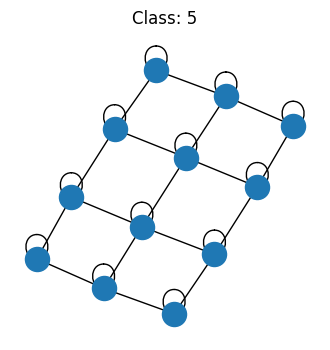

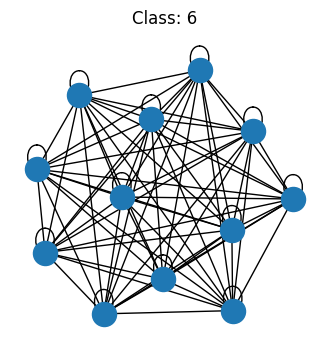

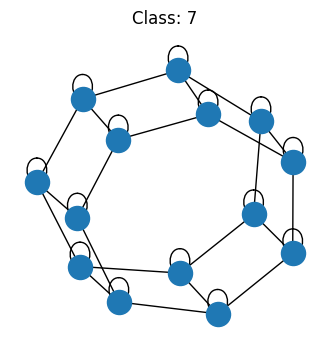

In [4]:
dataset = MiniGCDataset(8, 10, 20, seed=0)

# Visualise one graph for each of the 8 classes.
for c in range(8):
    graph, label = dataset[c]
    fig, ax = plt.subplots(figsize=(4, 4))
    nx.draw(to_networkx(graph, to_undirected=True), ax=ax)
    ax.set_title('Class: {:d}'.format(label))
    plt.show()

# Generate train, validation and test datasets

## Add node and edge features

In [5]:
# Add node and edge features to graphs.
def add_node_edge_features(dataset):
    for graph, _ in dataset:
        # Node feature is the in-degree. Self-loops are included, as in DGL.
        graph.x = degree(
            graph.edge_index[1], num_nodes=graph.num_nodes
        ).view(-1, 1).float()
        # No edge information is available, so use a scalar one feature.
        graph.edge_attr = torch.ones(graph.edge_index.size(1), 1)
    return dataset


# Use separate fixed seeds so validation and test are independently generated.
trainset = add_node_edge_features(MiniGCDataset(350, 10, 20, seed=0))
testset = add_node_edge_features(MiniGCDataset(100, 10, 20, seed=1))
valset = add_node_edge_features(MiniGCDataset(100, 10, 20, seed=2))
print(trainset[0])

(Data(edge_index=[2, 45], num_nodes=15, x=[15, 1], edge_attr=[45, 1]), tensor(0))


## Define the collate function to prepare a batch of PyG graphs

The `Batch` object concatenates node and edge tensors and stores a `batch` vector that identifies the graph for every node.

In [6]:
def collate(samples):
    # Input sample is a list of (PyG graph, label) pairs.
    graphs, labels = map(list, zip(*samples))
    batch_graphs = Batch.from_data_list(graphs)
    batch_labels = torch.tensor(labels, dtype=torch.long)

    # Normalization with respect to graph sizes.
    batch_norm_n = torch.cat([
        torch.full((graph.num_nodes, 1), 1.0 / graph.num_nodes**0.5)
        for graph in graphs
    ])
    batch_norm_e = torch.cat([
        torch.full((graph.edge_index.size(1), 1), 1.0 / graph.edge_index.size(1)**0.5)
        for graph in graphs
    ])
    return batch_graphs, batch_labels, batch_norm_n, batch_norm_e


batch_size = 10
train_loader = DataLoader(
    trainset, batch_size=batch_size, shuffle=True, collate_fn=collate
)
batch_graphs, batch_labels, batch_norm_n, batch_norm_e = list(train_loader)[0]
print(batch_graphs)
print(batch_labels)
print('batch_norm_n:', batch_norm_n.size())
print('batch_norm_e:', batch_norm_e.size())
print('batch_x:', batch_graphs.x.size())
print('batch_e:', batch_graphs.edge_attr.size())

DataBatch(edge_index=[2, 832], num_nodes=124, x=[124, 1], edge_attr=[832, 1], batch=[124], ptr=[11])
tensor([2, 4, 5, 2, 7, 3, 6, 3, 2, 0])
batch_norm_n: torch.Size([124, 1])
batch_norm_e: torch.Size([832, 1])
batch_x: torch.Size([124, 1])
batch_e: torch.Size([832, 1])


## Question 1: Design the GatedGCN network with PyG

Node and edge update equations:

$$
h_i^{\ell+1} = h_i^{\ell} + \operatorname{ReLU}\left(\operatorname{BN}\left(A^\ell h_i^\ell + \sum_{j\sim i} \eta(e_{ij}^\ell) \odot B^\ell h_j^\ell\right)\right),
$$
$$
e_{ij}^{\ell+1} = e_{ij}^\ell + \operatorname{ReLU}\left(\operatorname{BN}\left(C^\ell e_{ij}^\ell + D^\ell h_i^\ell + E^\ell h_j^\ell\right)\right),
$$
where
$$
\eta(e_{ij}^\ell) = \frac{\sigma(e_{ij}^\ell)}{\sum_{j'\sim i}\sigma(e_{ij'}^\ell)+\varepsilon}.
$$

In PyG, `edge_index[0]` is the source node $j$ and `edge_index[1]` is the destination node $i$. `GatedGCN_layer` subclasses PyG `MessagePassing`: `propagate()` gathers source-node features, calls `message()`, and sums messages at each destination. The edge update and gate are computed explicitly before propagation.

In [7]:
# MLP layer for classification
class MLP_layer(nn.Module):
    def __init__(self, input_dim, output_dim, L=2):
        super().__init__()
        layers = [nn.Linear(input_dim, input_dim, bias=True) for _ in range(L)]
        layers.append(nn.Linear(input_dim, output_dim, bias=True))
        self.FC_layers = nn.ModuleList(layers)
        self.L = L

    def forward(self, x):
        y = x
        for layer in self.FC_layers[:-1]:
            y = torch.relu(layer(y))
        return self.FC_layers[-1](y)


class GatedGCN_layer(MessagePassing):
    # PyG uses this declaration to generate propagate() with these inputs.
    propagate_type = {'x': torch.Tensor, 'gate': torch.Tensor}
    def __init__(self, input_dim, output_dim):
        super().__init__(aggr='add', flow='source_to_target', node_dim=0)
        self.A = nn.Linear(input_dim, output_dim, bias=True)
        self.B = nn.Linear(input_dim, output_dim, bias=True)
        self.C = nn.Linear(input_dim, output_dim, bias=True)
        self.D = nn.Linear(input_dim, output_dim, bias=True)
        self.E = nn.Linear(input_dim, output_dim, bias=True)
        self.bn_node_h = nn.BatchNorm1d(output_dim)
        self.bn_node_e = nn.BatchNorm1d(output_dim)

    def forward(self, graph, h, e, snorm_n, snorm_e):
        h_in = h
        e_in = e
        src, dst = graph.edge_index

        Ahi = self.A(h)
        Bh = self.B(h)
        Dh = self.D(h)
        Eh = self.E(h)
        Ce = self.C(e)

        # Update each edge using its source and destination node features.
        eij = Ce + Dh[dst] + Eh[src]
        sigmaij = torch.sigmoid(eij)

        # PyG gathers Bh_j in message(), then sums messages at each destination.
        messages = self.propagate(
            graph.edge_index,
            x=Bh,
            gate=sigmaij,
            size=(h.size(0), h.size(0)),
        )
        weighted_sum, normalizer = messages.split(Ahi.size(-1), dim=-1)
        h = Ahi + weighted_sum / (normalizer + 1e-9)
        e = eij

        # Normalize activations with respect to graph sizes.
        h = h * snorm_n
        e = e * snorm_e

        # Step 3: batch norm -> ReLU -> residual connection.
        h = self.bn_node_h(h)
        e = self.bn_node_e(e)
        h = h_in + torch.relu(h)
        e = e_in + torch.relu(e)
        return h, e

    def message(self, x_j, gate):
        # Concatenate weighted node messages and gates so propagate() sums both.
        return torch.cat((gate * x_j, gate), dim=-1)


class GatedGCN_net(nn.Module):
    def __init__(self, net_parameters):
        super().__init__()
        input_dim = net_parameters['input_dim']
        hidden_dim = net_parameters['hidden_dim']
        output_dim = net_parameters['output_dim']
        L = net_parameters['L']
        self.embedding_h = nn.Linear(input_dim, hidden_dim)
        self.embedding_e = nn.Linear(1, hidden_dim)
        self.GatedGCN_layers = nn.ModuleList([
            GatedGCN_layer(hidden_dim, hidden_dim) for _ in range(L)
        ])
        self.MLP_layer = MLP_layer(hidden_dim, output_dim)

    def forward(self, graph, h, e, snorm_n, snorm_e):
        h = self.embedding_h(h)
        e = self.embedding_e(e)
        for layer in self.GatedGCN_layers:
            h, e = layer(graph, h, e, snorm_n, snorm_e)
        y = global_mean_pool(h, graph.batch)
        return self.MLP_layer(y)

    def loss(self, y_scores, y_labels):
        return nn.CrossEntropyLoss()(y_scores, y_labels)

    def accuracy(self, scores, targets):
        predictions = scores.detach().argmax(dim=1)
        return (predictions == targets).float().sum().item()


net_parameters = {
    'input_dim': 1,
    'hidden_dim': 128,
    'output_dim': 8,
    'L': 4,
}
net = GatedGCN_net(net_parameters)
print(net)


def display_num_param(net):
    nb_param = sum(param.numel() for param in net.parameters())
    print('Number of parameters: {} ({:.2f} million)'.format(
        nb_param, nb_param / 1e6
    ))
    return nb_param / 1e6


_ = display_num_param(net)

GatedGCN_net(
  (embedding_h): Linear(in_features=1, out_features=128, bias=True)
  (embedding_e): Linear(in_features=1, out_features=128, bias=True)
  (GatedGCN_layers): ModuleList(
    (0-3): 4 x GatedGCN_layer()
  )
  (MLP_layer): MLP_layer(
    (FC_layers): ModuleList(
      (0-1): 2 x Linear(in_features=128, out_features=128, bias=True)
      (2): Linear(in_features=128, out_features=8, bias=True)
    )
  )
)
Number of parameters: 366856 (0.37 million)


# Train the network

In [8]:
def run_one_epoch(net, data_loader, train=True):
    net.train() if train else net.eval()
    epoch_loss = 0.0
    epoch_acc = 0.0
    nb_data = 0

    for batch_graphs, batch_labels, batch_snorm_n, batch_snorm_e in data_loader:
        batch_x = batch_graphs.x
        batch_e = batch_graphs.edge_attr
        batch_scores = net(batch_graphs, batch_x, batch_e, batch_snorm_n, batch_snorm_e)
        loss = net.loss(batch_scores, batch_labels)
        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        epoch_loss += loss.detach().item()
        epoch_acc += net.accuracy(batch_scores, batch_labels)
        nb_data += batch_labels.size(0)

    epoch_loss /= len(data_loader)
    epoch_acc /= nb_data
    return epoch_loss, epoch_acc


train_loader = DataLoader(trainset, batch_size=50, shuffle=True, collate_fn=collate)
test_loader = DataLoader(testset, batch_size=50, shuffle=False, collate_fn=collate)
val_loader = DataLoader(valset, batch_size=50, shuffle=False, collate_fn=collate)

torch.manual_seed(0)
net = GatedGCN_net(net_parameters)
display_num_param(net)
optimizer = torch.optim.Adam(net.parameters(), lr=0.0001)

for epoch in range(50):
    start = time.time()
    epoch_train_loss, epoch_train_acc = run_one_epoch(net, train_loader, True)
    with torch.no_grad():
        epoch_test_loss, epoch_test_acc = run_one_epoch(net, test_loader, False)
        epoch_val_loss, epoch_val_acc = run_one_epoch(net, val_loader, False)
    if not epoch % 2:
        print('Epoch {}, time {:.4f}, train_loss: {:.4f}, test_loss: {:.4f}, val_loss: {:.4f}'.format(
            epoch, time.time() - start, epoch_train_loss, epoch_test_loss, epoch_val_loss
        ))
        print('                      train_acc: {:.4f}, test_acc: {:.4f}, val_acc: {:.4f}'.format(
            epoch_train_acc, epoch_test_acc, epoch_val_acc
        ))

Number of parameters: 366856 (0.37 million)
Epoch 0, time 0.3641, train_loss: 2.0473, test_loss: 2.0467, val_loss: 2.0489
                      train_acc: 0.2600, test_acc: 0.1600, val_acc: 0.1600
Epoch 2, time 0.3994, train_loss: 1.6551, test_loss: 1.7923, val_loss: 1.7915
                      train_acc: 0.5914, test_acc: 0.3400, val_acc: 0.3000
Epoch 4, time 0.3592, train_loss: 1.4501, test_loss: 1.5385, val_loss: 1.5370
                      train_acc: 0.6114, test_acc: 0.5900, val_acc: 0.6000
Epoch 6, time 0.2964, train_loss: 1.2768, test_loss: 1.3112, val_loss: 1.3055
                      train_acc: 0.7029, test_acc: 0.6800, val_acc: 0.7300
Epoch 8, time 0.3000, train_loss: 1.1413, test_loss: 1.1159, val_loss: 1.1085
                      train_acc: 0.7286, test_acc: 0.6600, val_acc: 0.6700
Epoch 10, time 0.3459, train_loss: 0.9859, test_loss: 0.9688, val_loss: 0.9576
                      train_acc: 0.7829, test_acc: 0.6800, val_acc: 0.7100
Epoch 12, time 0.3361, train_loss: 0.